In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [3]:
df = sns.load_dataset("Iris")
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
89,5.5,2.5,4.0,1.3,versicolor
122,7.7,2.8,6.7,2.0,virginica
140,6.7,3.1,5.6,2.4,virginica
45,4.8,3.0,1.4,0.3,setosa
68,6.2,2.2,4.5,1.5,versicolor
144,6.7,3.3,5.7,2.5,virginica
109,7.2,3.6,6.1,2.5,virginica
10,5.4,3.7,1.5,0.2,setosa
11,4.8,3.4,1.6,0.2,setosa
139,6.9,3.1,5.4,2.1,virginica


In [4]:
df.shape

(150, 5)

In [5]:
df.rename(columns={'sepal_length':'sl','sepal_width':'sw','petal_length':'pl','petal_width':'pw'},inplace=True)
df.sample(2)

,sl,sw,pl,pw,species
53,5.5,2.3,4.0,1.3,versicolor
44,5.1,3.8,1.9,0.4,setosa


In [6]:
setosa = df[df['species']=='setosa']
virginica = df[df['species']=='virginica']
versicolor = df[df['species']=='versicolor']
print(setosa.shape)
print(virginica.shape)
print(versicolor.shape)

(50, 5)
(50, 5)
(50, 5)


Measures of Spread  
Measures of spread gives us an idea of how much the data is spread or varying. Some important measures of spread are :
1. Range
2. Interquartile Range (IQR)
3. Variance
4. Standard Deviation

1. Range  
The range describes the difference between the largest and the smallest points in your data.

In [7]:
range = np.max(setosa['pl']) - np.min(setosa['pl'])
print("The range is : ",range)

The range is :  0.8999999999999999


2. Percentiles  
A percentile is a measure used in statistics indicating the value below which a given percentage of observations in a group of observations falls.   
For example, the 20th percentile is the value below which 20% of the observations may be found

In [8]:
p = np.percentile(setosa['pl'],90)
p

np.float64(1.7)

3. Quartiles  
Quartiles are the values that divide a list of numbers into quarters:  
Put the list of numbers in order  
Then cut the list into four equal parts  
The Quartiles are at the "cuts"  

In [9]:
ft = np.percentile(setosa['pl'],25)
s = np.percentile(setosa['pl'],50)
t = np.percentile(setosa['pl'],75)
fh = np.percentile(setosa['pl'],100)
print(ft, s, t, fh)

1.4 1.5 1.5750000000000002 1.9


4. Interquartile Range  
The interquartile range (IQR) is a measure of statistical dispersion between upper (75th) and lower (25th) quartiles.

In [10]:
iqr = t - ft
print(iqr)

0.17500000000000027


5. Mean Absoulute Deviation:  
The Absolute Deviation from Mean, also called Mean Absolute Deviation (MAD), describe the variation in the data set, in sense that it tells the average absolute distance of each data point in the set. It is calculated as  

            MEAN ABSOLUTE DEVIATION = 1/N (Summation from i=1 to n|Xi - Xbar|)

Example
2,5,1,6,7,3,11
The mean is 5
(|2-5| + |5-5| + |1-5| + |6-5| + |7-5| + |3-5| +|11-5| )/t 
3+0+4+1+2+2+6=18/7=2.5


6. Variance  
Variance measures how far are data points spread out from the mean.
The variance is computed by finding the difference between every data point and the mean, squaring them, summing them up and then taking the average of those numbers.  

        Variance = 1/N (summation from i=1 to n (xi - xbar)^2 )

The squares are used during the calculation because they weight outliers more heavily than points that are near to the mean.  
This prevents that differences above the mean neutralize those below the mean.  
Example  
2,5,1,6,7,3,11  
The mean is 5  
((2-5)*2 + (5-5)*2 + (1-5)*2 + (6-5)*2 + (7-5)*2 + (3-5)*2 + (11-5)^2)/7  
9+0+16+1+4+4+36=70/7=10  


In [11]:
v = np.var(setosa['pl'])
v

0.02955600000000001

The problem with Variance  
The problem with Variance is that because of the squaring, it is not in the same unit of measurement as the original data.  
Let's say you are dealing with a dataset that contains centimeter values. Your variance would be in squared centimeters and therefore not the best measurement.

7. Variance Vs Median Absolute Deviation  
Variance is easy to work with in comparision to MAD as it works on squaring(a smooth function) the deviation in comparison to MAD where we use modulus (a non smooth function).  


Mathematically speaking smooth functions are easier to work with in comparison to non smooth functions

8. Standard Deviation
The square root of Variance is called the Standard Deviation. It is calculated as:    

                 Standard Deviation = variance^1.5 (or) √variance  

Example  
2,5,1,6,7,3,11  
The mean is 5  
((2-5)*2 + (5-5)*2 + (1-5)*2 + (6-5)*2 + (7-5)*2 + (3-5)^2 + (11-5)^2)/7  
9+0+16+1+4+4+36=70/7=10  
SD=sqrt(10)=3.16  

In [12]:
s = np.std(setosa['pl'])
s

0.17191858538273286

9. Median Absolute Deviation  
MAD js the median of all the number obtained from subtracting and calculating the absolute value of every observation with the median.  
Example:  
1,3,5,6,7,8,9  
Median is 6  
(1-6|.|3-6|.|5-6|.|6-6|.|7-6|.|8-6|.|9-6| )
5,3,1,0,1,2,3  
0,1,1,2,3,3,5  
Median Absolute Deviation is 2  

In [13]:
from statsmodels import robust
MAD = robust.mad(setosa['pl'])
MAD

np.float64(0.14826022185056031)

In [14]:
a = np.array([1,3,5,6,7,8,9])
print(np.median(a))
print(robust.mad(a))

6.0
2.965204437011204


Scaled MAD (what statsmodels.robust.mad() returns)  

            Scaled MAD = 𝑀𝐴𝐷/0.6745  

So:

            2 / 0.6745 ≈ 2.96

🤯 Why divide by 0.6745?  
This is NOT random.  
It comes from properties of the Normal Distribution.  
Key idea:  

For a normal distribution:

            𝑀𝐴𝐷 ≈ 0.6745 × 𝜎

Where:
σ = standard deviation

So we invert it:

            𝜎≈𝑀𝐴𝐷/0.6745
​
👉 That’s exactly what robust.mad() does.

10. Standard Deviation Vs Median Absolute Deviation   
Just like mean vs median, Median Absolute Deviation is free from the effects of outliers from which Standard Deviation can suffer

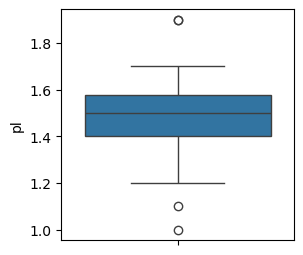

In [20]:
plt.figure(figsize=(3,3))
sns.boxplot(setosa['pl'])
plt.show()

C:\Users\bathr\AppData\Local\Temp\ipykernel_16192\459467203.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'species', y = 'pl', data=df, palette='Set2')


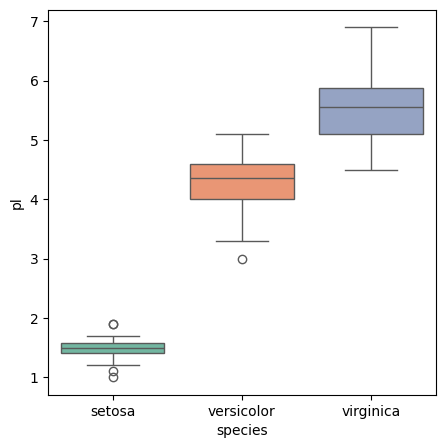

In [24]:
plt.figure(figsize=(5,5))
sns.boxplot(x = 'species', y = 'pl', data=df, palette='Set2')
plt.show()